## PM2.5 Forecasting Using Exponential Smoothing (Holt–Winters)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [48]:
df = pd.read_csv("../../data/master/PM25_2020 cleaned Master_20_23.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.dropna(subset=["City", "Date", "PM25"])
df = df.sort_values(["City", "Date"]).reset_index(drop=True)
df["PM25"] = pd.to_numeric(df["PM25"], errors="coerce")
df = df.dropna(subset=["PM25"])

print("PM25 dtype:", df["PM25"].dtype)
print("PM25 missing:", df["PM25"].isna().sum())

PM25 dtype: float64
PM25 missing: 0


## 1. Select Cities for Modeling
Exponential Smoothing is fit **separately for each city**, since each city is its own time series.
To keep runtime manageable, we start with the **top 10 cities** (most observations).

In [17]:
top_cities = df["City"].value_counts().head(10).index.tolist()
top_cities

['Montréal',
 'Toronto',
 'Edmonton',
 'Quebec',
 'Saint John',
 'Kitimat',
 'Hamilton',
 'Calgary',
 'Fort Mckay',
 'Sarnia']

## 2. Time-Based Train/Test Split
We use a chronological split to avoid data leakage:
- Train: 2020–2022  
- Test: 2023  
Cutoff date: 2023-01-01

In [9]:
cutoff = pd.Timestamp("2023-01-01")

## 3. Fit Exponential Smoothing (Holt–Winters) per City

In [44]:
results = []
forecast_store = {}

for city in top_cities:
    print(f"Processing: {city}")

    city_df = df[df["City"] == city].copy()
    city_df = city_df.sort_values("Date")

    city_df = city_df.drop_duplicates(subset=["Date"], keep="last")

    city_df = city_df.set_index("Date")

    city_df = city_df.asfreq("D")

    y_train = city_df.loc[city_df.index < cutoff, "PM25"].dropna()
    y_test  = city_df.loc[city_df.index >= cutoff, "PM25"].dropna()

    if len(y_train) < 30 or len(y_test) < 7:
        print(f"Skipping {city} (train={len(y_train)}, test={len(y_test)})")
        continue

    try:
        model = ExponentialSmoothing(
            y_train,
            trend="add",
            seasonal="add",
            seasonal_periods=7
        ).fit(optimized=True)

        y_pred = model.forecast(steps=len(y_test))
        y_pred = pd.Series(y_pred, index=y_test.index)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        results.append({
            "City": city,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2,
            "Train_Size": len(y_train),
            "Test_Size": len(y_test)
        })

        forecast_store[city] = (y_test, y_pred)

        print(f"Done: {city} | MAE={mae:.3f}, RMSE={rmse:.3f}, R2={r2:.3f}")

    except Exception as e:
        print(f"Failed for {city}: {e}")

Processing: Montréal
Done: Montréal | MAE=5.359, RMSE=8.562, R2=-0.078
Processing: Toronto
Done: Toronto | MAE=5.490, RMSE=8.295, R2=-0.040
Processing: Edmonton
Done: Edmonton | MAE=23.587, RMSE=32.861, R2=-0.199
Processing: Quebec
Done: Quebec | MAE=7.265, RMSE=8.894, R2=-0.562
Processing: Saint John
Done: Saint John | MAE=3.467, RMSE=3.965, R2=-0.724
Processing: Kitimat
Done: Kitimat | MAE=1.864, RMSE=3.777, R2=-0.022
Processing: Hamilton
Done: Hamilton | MAE=5.105, RMSE=8.967, R2=-0.006
Processing: Fort Mckay
Done: Fort Mckay | MAE=19.857, RMSE=46.066, R2=-0.146
Processing: Calgary
Done: Calgary | MAE=9.257, RMSE=17.322, R2=-0.009
Processing: Sarnia
Done: Sarnia | MAE=5.320, RMSE=10.347, R2=-0.002


In [46]:
results_df = pd.DataFrame(results).sort_values("MAE")
results_df

,City,MAE,RMSE,R2,Train_Size,Test_Size
5,Kitimat,1.863553,3.777220,-0.021952,1096,365
4,Saint John,3.466785,3.965200,-0.723740,1096,365
6,Hamilton,5.104536,8.967139,-0.006434,1096,365
9,Sarnia,5.319932,10.346806,-0.001649,1096,365
0,Montréal,5.358890,8.561565,-0.077865,1096,365
1,Toronto,5.490023,8.294904,-0.040137,1096,365
3,Quebec,7.265042,8.894358,-0.561836,1096,365
8,Calgary,9.257071,17.322203,-0.008741,1096,365
7,Fort Mckay,19.856784,46.066303,-0.145523,1096,365
2,Edmonton,23.587086,32.860559,-0.199449,1096,365


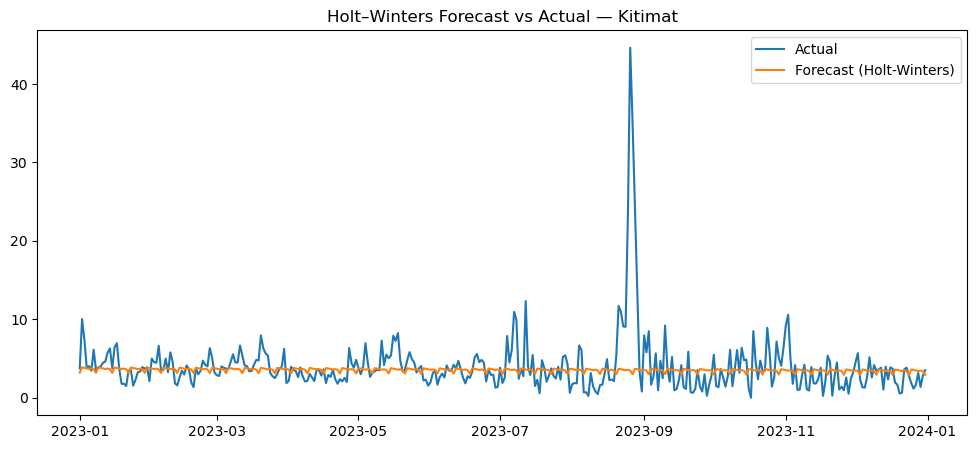

In [52]:
example_city = results_df.iloc[0]["City"]
y_test_plot, y_pred_plot = forecast_store[example_city]

plt.figure(figsize=(12,5))
plt.plot(y_test_plot.index, y_test_plot.values, label="Actual")
plt.plot(y_pred_plot.index, y_pred_plot.values, label="Forecast (Holt-Winters)")
plt.title(f"Holt–Winters Forecast vs Actual — {example_city}")
plt.legend()
plt.show()

In [56]:
results_df.to_csv("../results/PM25_ExponentialSmoothing_results.csv", index=False)
print("Saved: ../results/PM25_ExponentialSmoothing_results.csv")

Saved: ../results/PM25_ExponentialSmoothing_results.csv
